In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator

# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

In [2]:
from src.dataloading import BaseLineDataLoaderManager, GraphDataLoaderManager
n_epochs        = 10
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

baselinedata             = BaseLineDataLoaderManager(data_orchestrator)
graphdataloader_ig       = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()
from src.models import SimpleGCNModel 

model1 = SimpleGCNModel(graphdataloader_ig, name = 'model 1',verbose = 0)
model1.set_model_hparams()
model1.set_global_hparams(**global_hparams)
model1.train()


==                   model_1                    ==


Training epochs: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:10<00:00,  1.07s/it]


In [3]:
model1.save()

✓ Model saved: Wissdaten/ZKI-PH4/deschrijvers_wissdaten/project_utilities/infectious_disease_gnn/models/model_1.pt


In [4]:
# model1.forecast()
# model1.show_forecasts(26).show()

In [5]:
# model1.config_info

In [6]:
# model_weights = model1.model.state_dict()

In [7]:
from src.models.deep.deepmodel import DeepModel
DeepModel._childclasses

{'nodelstmmodel': src.models.deep.vanilla.nodelstm.NodeLSTMModel,
 'nodegrumodel': src.models.deep.vanilla.nodegru.NodeGRUModel,
 'nodebilstmmodel': src.models.deep.vanilla.nodebilstm.NodeBiLSTMModel,
 'seqnodelstmmodel': src.models.deep.vanilla.seqnodelstm.SeqNodeLSTMModel,
 'simplegcnmodel': src.models.deep.gnns.simplegcn.SimpleGCNModel,
 'gatv2model': src.models.deep.gnns.gatv2.GATv2Model,
 'gatv2lstmmodel': src.models.deep.gnns.gatv2lstm.GATv2LSTMModel}

In [8]:
model2 = DeepModel.load('model_1')


# error! not correctly loaded!

loading model initiated
model path found


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/modelmanager.py:92: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  save_dict = torch.load(filepath, map

save dict loaded


In [10]:
model2.model.state_dict()

OrderedDict([('spatial_convs.0.bias',
              tensor([ 0.0191,  0.0466,  0.0154,  0.0413,  0.0170,  0.0705, -0.0533,  0.0126,
                       0.0040,  0.0360,  0.0372,  0.0766,  0.0762,  0.0599,  0.0267,  0.0324,
                       0.0374, -0.0164, -0.0064,  0.0562,  0.0418, -0.0036,  0.0082,  0.0103,
                       0.0009,  0.0079,  0.0793, -0.0132,  0.0336,  0.0556,  0.0798,  0.0397,
                      -0.0056,  0.0101,  0.0760,  0.0613, -0.0046, -0.0477,  0.0050,  0.0422,
                       0.0113,  0.0543,  0.0343, -0.0066, -0.0296,  0.0340,  0.0548,  0.0741,
                       0.0146,  0.0395,  0.0416,  0.0484,  0.0137,  0.0472,  0.0677,  0.0394,
                       0.0093,  0.0197,  0.0322, -0.0126,  0.0388,  0.0152,  0.0953,  0.0655],
                     device='cuda:0')),
             ('spatial_convs.0.lin.weight',
              tensor([[-9.0085e-03, -1.2873e-01,  2.0218e-03],
                      [ 2.9962e-01,  1.2067e-01,  6.1320e-02],

In [ ]:
model2.forecast()

SimpleGCNModel(name='model_1_loaded')

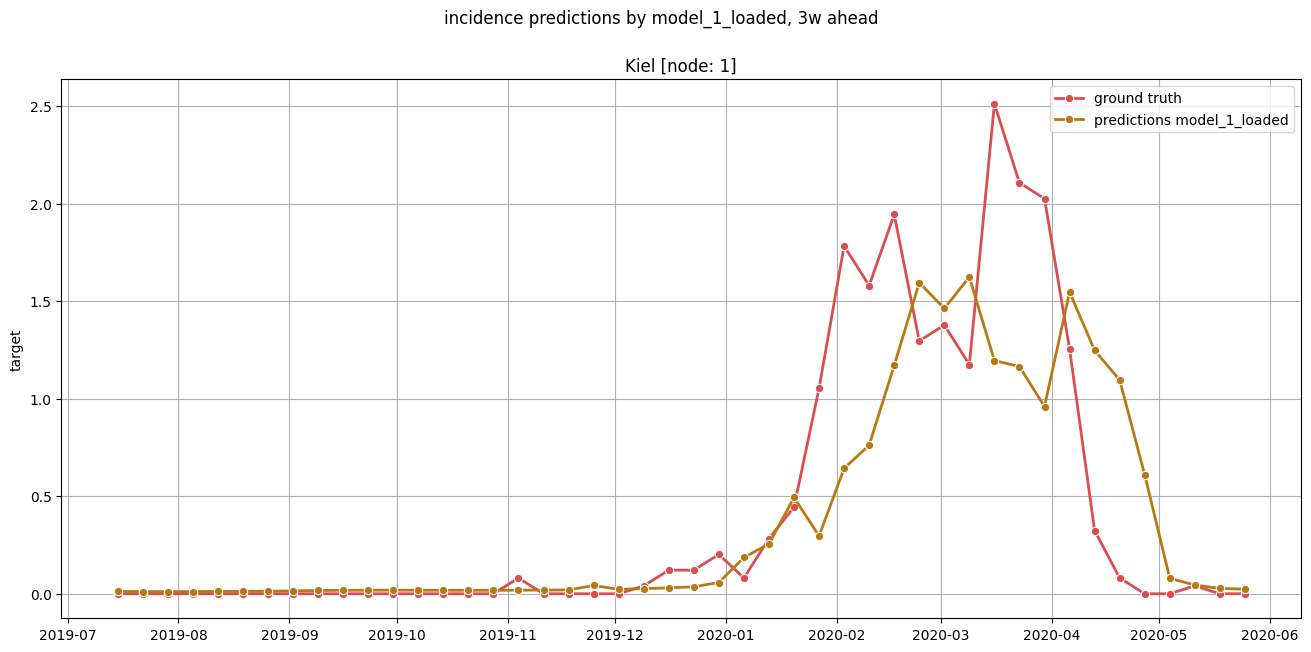

In [14]:
model2.show_forecasts().show()

In [ ]:
output['model_class'].lower() in DeepModel._childclasses

True

In [ ]:
output['dataloadermanager']

<GraphDataLoaderManager(dataloaders at .dataloader_collection)>

In [ ]:
if output['model_class'].lower() in DeepModel._childclasses:
    model_instance = DeepModel._childclasses[output['model_class'].lower()](name = output['name']+"_loaded", dataloadermanager=output['dataloadermanager'])
    model_instance.model.state_dict()

SimpleGCNModel(name='model_1_loaded')